In [ ]:
# Import the required libraries and load the DDXPlus training, validation, and test datasets.
import pandas as pd
train_df = pd.read_csv("/content/ddxplus/train.csv")
valid_df = pd.read_csv("/content/ddxplus/validate.csv")
test_df = pd.read_csv("/content/ddxplus/test.csv")

In [ ]:
print(train_df.shape) # Display the dataset dimensions and preview sample patient records.
train_df.head()

(1025602, 6)


,AGE,DIFFERENTIAL_DIAGNOSIS,SEX,PATHOLOGY,EVIDENCES,INITIAL_EVIDENCE
0,18,"[['Bronchitis', 0.19171203430383882], ['Pneumo...",M,URTI,"['E_48', 'E_50', 'E_53', 'E_54_@_V_161', 'E_54...",E_91
1,21,"[['HIV (initial infection)', 0.518950056440760...",M,HIV (initial infection),"['E_9', 'E_27', 'E_50', 'E_51', 'E_53', 'E_54_...",E_50
2,19,"[['Bronchitis', 0.11278064619119596], ['Pneumo...",F,Pneumonia,"['E_53', 'E_54_@_V_179', 'E_54_@_V_192', 'E_55...",E_77
3,34,"[['URTI', 0.23859396799565236], ['Cluster head...",F,URTI,"['E_48', 'E_53', 'E_54_@_V_183', 'E_55_@_V_89'...",E_53
4,36,"[['URTI', 0.23677812769175735], ['Influenza', ...",M,URTI,"['E_49', 'E_50', 'E_53', 'E_54_@_V_183', 'E_55...",E_201


In [ ]:
train_df.info() # Inspect the dataset structure, feature types, and missing value information.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025602 entries, 0 to 1025601
Data columns (total 6 columns):
 #   Column                  Non-Null Count    Dtype 
---  ------                  --------------    ----- 
 0   AGE                     1025602 non-null  int64 
 1   DIFFERENTIAL_DIAGNOSIS  1025602 non-null  object
 2   SEX                     1025602 non-null  object
 3   PATHOLOGY               1025602 non-null  object
 4   EVIDENCES               1025602 non-null  object
 5   INITIAL_EVIDENCE        1025602 non-null  object
dtypes: int64(1), object(5)
memory usage: 46.9+ MB


In [ ]:
train_df.columns # List all available features included in the dataset.

Index(['AGE', 'DIFFERENTIAL_DIAGNOSIS', 'SEX', 'PATHOLOGY', 'EVIDENCES',
       'INITIAL_EVIDENCE'],
      dtype='object')

In [ ]:
train_df.head() # Examine the raw format of patient records and symptom evidence data.

,AGE,DIFFERENTIAL_DIAGNOSIS,SEX,PATHOLOGY,EVIDENCES,INITIAL_EVIDENCE
0,18,"[['Bronchitis', 0.19171203430383882], ['Pneumo...",M,URTI,"['E_48', 'E_50', 'E_53', 'E_54_@_V_161', 'E_54...",E_91
1,21,"[['HIV (initial infection)', 0.518950056440760...",M,HIV (initial infection),"['E_9', 'E_27', 'E_50', 'E_51', 'E_53', 'E_54_...",E_50
2,19,"[['Bronchitis', 0.11278064619119596], ['Pneumo...",F,Pneumonia,"['E_53', 'E_54_@_V_179', 'E_54_@_V_192', 'E_55...",E_77
3,34,"[['URTI', 0.23859396799565236], ['Cluster head...",F,URTI,"['E_48', 'E_53', 'E_54_@_V_183', 'E_55_@_V_89'...",E_53
4,36,"[['URTI', 0.23677812769175735], ['Influenza', ...",M,URTI,"['E_49', 'E_50', 'E_53', 'E_54_@_V_183', 'E_55...",E_201


In [ ]:
train_df.isnull().sum() # Check the dataset for missing or null values across all features.

,0
AGE,0
DIFFERENTIAL_DIAGNOSIS,0
SEX,0
PATHOLOGY,0
EVIDENCES,0
INITIAL_EVIDENCE,0


In [ ]:
train_df.describe() # Generate summary statistics for the numerical features in the dataset.

,AGE
count,1.025602e+06
mean,3.971484e+01
std,2.271728e+01
min,0.000000e+00
25%,2.200000e+01
50%,3.900000e+01
75%,5.600000e+01
max,1.090000e+02


In [ ]:
import ast # Define the preprocessing pipeline for encoding demographic and symptom evidence features.
import pandas as pd

from sklearn.preprocessing import MultiLabelBinarizer

def preprocess_dataset(df, mlb=None, fit_mlb=False):

    df = df.copy()

    # Convert evidence strings to lists
    df['EVIDENCES'] = df['EVIDENCES'].apply(ast.literal_eval)

    # Encode sex
    df['SEX'] = df['SEX'].map({
        'M': 0,
        'F': 1
    })

    # Multi-label encode evidences
    if fit_mlb:
        evidence_matrix = mlb.fit_transform(df['EVIDENCES'])
    else:
        evidence_matrix = mlb.transform(df['EVIDENCES'])

    evidence_df = pd.DataFrame(
        evidence_matrix,
        columns=mlb.classes_
    )

    # Final feature matrix
    X = pd.concat([
        df[['AGE', 'SEX']].reset_index(drop=True),
        evidence_df.reset_index(drop=True)
    ], axis=1)

    y = df['PATHOLOGY']

    return X, y

In [ ]:
mlb = MultiLabelBinarizer() # Apply preprocessing and transform symptom evidence into machine learning feature vectors.

X_train, y_train = preprocess_dataset(
    train_df,
    mlb=mlb,
    fit_mlb=True
)

In [ ]:
import pandas as pd # Import the libraries required for sparse feature encoding and memory-efficient preprocessing.
import ast

from sklearn.preprocessing import MultiLabelBinarizer
from scipy.sparse import hstack, csr_matrix

In [ ]:
def preprocess_sparse(df, mlb=None, fit_mlb=False): # Define a sparse preprocessing pipeline to efficiently encode large-scale symptom evidence data.

    # Convert evidence strings
    evidences = df['EVIDENCES'].apply(ast.literal_eval)

    # Encode sex
    sex = df['SEX'].map({
        'M': 0,
        'F': 1
    }).values.reshape(-1, 1)

    # Age
    age = df['AGE'].values.reshape(-1, 1)

    # Sparse evidence encoding
    if fit_mlb:
        evidence_sparse = mlb.fit_transform(evidences)
    else:
        evidence_sparse = mlb.transform(evidences)

    # Combine ALL features into sparse matrix
    X = hstack([
        csr_matrix(age),
        csr_matrix(sex),
        csr_matrix(evidence_sparse)
    ])

    y = df['PATHOLOGY']

    return X, y

In [ ]:
import pandas as pd # Reload the DDXPlus datasets for sparse preprocessing and model training.

train_df = pd.read_csv("/content/ddxplus/train.csv")
valid_df = pd.read_csv("/content/ddxplus/validate.csv")
test_df = pd.read_csv("/content/ddxplus/test.csv")

In [ ]:
mlb = MultiLabelBinarizer(sparse_output=True) # Initialize sparse multi-label encoding for transforming symptom evidence features.

X_train, y_train = preprocess_sparse(
    train_df,
    mlb=mlb,
    fit_mlb=True
)

In [ ]:
X_valid, y_valid = preprocess_sparse( # Apply sparse preprocessing to the validation dataset using the fitted evidence encoder.
    valid_df,
    mlb=mlb,
    fit_mlb=False
)

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:909: UserWarning: unknown class(es) ['E_133_@_V_186'] will be ignored
  warnings.warn(


In [ ]:
from sklearn.preprocessing import LabelEncoder # Encode disease labels into numerical classes for model training and evaluation.

label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train)
y_valid_encoded = label_encoder.transform(y_valid)

In [ ]:
print(X_train.shape) # Verify the dimensions of the preprocessed training and validation feature matrices.
print(X_valid.shape)

(1025602, 517)
(132448, 517)


In [ ]:
from sklearn.linear_model import LogisticRegression # Train the Logistic Regression classifier using the sparse preprocessed training data.

log_reg = LogisticRegression(
    solver='saga',
    max_iter=1000,
    n_jobs=-1
)

log_reg.fit(X_train, y_train_encoded)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


LogisticRegression(max_iter=1000, n_jobs=-1, solver='saga')

In [ ]:
y_pred = log_reg.predict(X_valid) # Generate disease predictions on the validation dataset using the trained Logistic Regression model.

In [ ]:
from sklearn.metrics import ( # Evaluate the Logistic Regression model using multiple multiclass classification metrics.
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef
)

accuracy = accuracy_score(y_valid_encoded, y_pred)

precision = precision_score(
    y_valid_encoded,
    y_pred,
    average='weighted'
)

recall = recall_score(
    y_valid_encoded,
    y_pred,
    average='weighted'
)

f1 = f1_score(
    y_valid_encoded,
    y_pred,
    average='weighted'
)

mcc = matthews_corrcoef(
    y_valid_encoded,
    y_pred
)

print("FINAL Logistic Regression Results")
print("-" * 50)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")
print(f"MCC      : {mcc:.4f}")

FINAL Logistic Regression Results
--------------------------------------------------
Accuracy : 0.9971
Precision: 0.9973
Recall   : 0.9971
F1-Score : 0.9971
MCC      : 0.9971


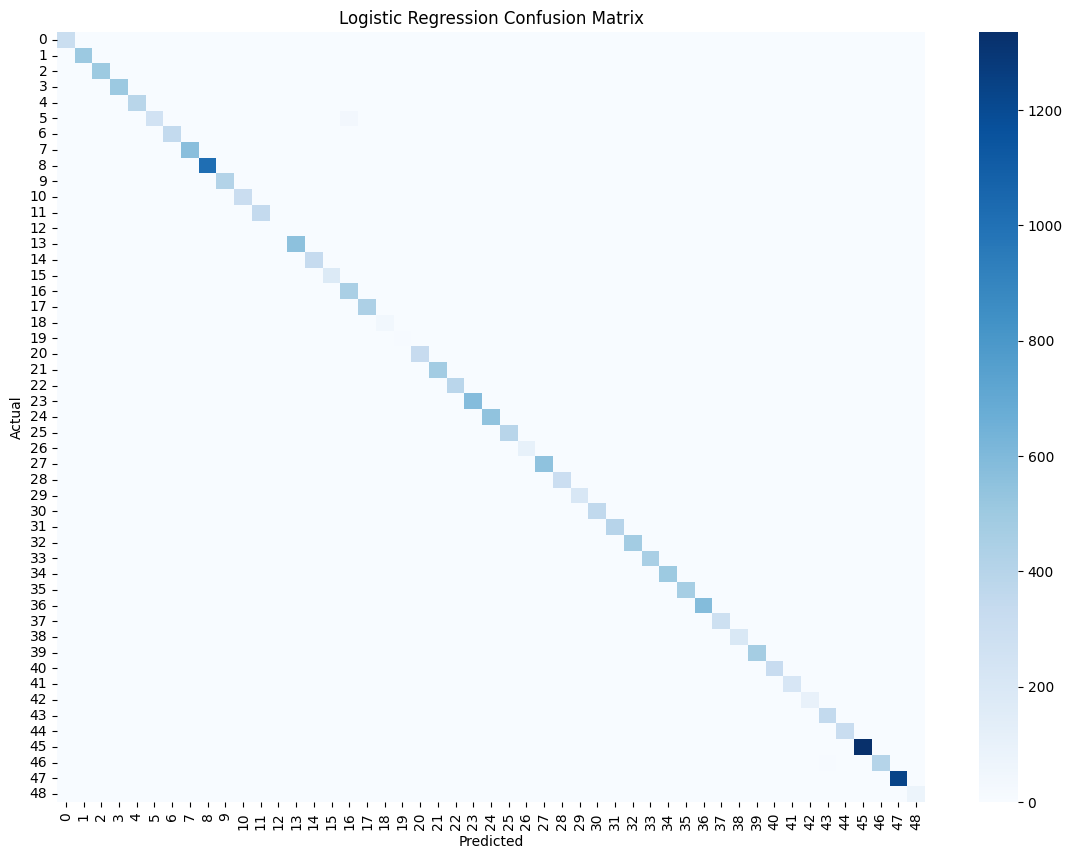

In [ ]:
import matplotlib.pyplot as plt # Visualize the classification performance of the Logistic Regression model using a confusion matrix heatmap.
import seaborn as sns

cm = confusion_matrix(y_valid_encoded, y_pred)

plt.figure(figsize=(14, 10))

sns.heatmap(
    cm,
    cmap="Blues"
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [ ]:
from sklearn.metrics import ( # Calculate and display the evaluation metrics and detailed classification performance of the Logistic Regression model.
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    classification_report,
    confusion_matrix
)

print("Logistic Regression Validation Results")
print("-" * 50)

accuracy = accuracy_score(y_valid_encoded, y_pred)

precision = precision_score(
    y_valid_encoded,
    y_pred,
    average='weighted'
)

recall = recall_score(
    y_valid_encoded,
    y_pred,
    average='weighted'
)

f1 = f1_score(
    y_valid_encoded,
    y_pred,
    average='weighted'
)

mcc = matthews_corrcoef(
    y_valid_encoded,
    y_pred
)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")
print(f"MCC      : {mcc:.4f}")

print("\nClassification Report")
print("-" * 50)

print(
    classification_report(
        y_valid_encoded,
        y_pred,
        target_names=label_encoder.classes_
    )
)

Logistic Regression Validation Results
--------------------------------------------------
Accuracy : 0.9972
Precision: 0.9974
Recall   : 0.9972
F1-Score : 0.9972
MCC      : 0.9971

Classification Report
--------------------------------------------------
                                          precision    recall  f1-score   support

     Acute COPD exacerbation / infection       1.00      1.00      1.00       307
                Acute dystonic reactions       1.00      1.00      1.00       509
                        Acute laryngitis       0.99      1.00      1.00       504
                      Acute otitis media       1.00      1.00      1.00       507
                   Acute pulmonary edema       1.00      1.00      1.00       386
                    Acute rhinosinusitis       1.00      0.86      0.92       297
                      Allergic sinusitis       1.00      1.00      1.00       349
                             Anaphylaxis       1.00      1.00      1.00       573
       